This notebook builds the modelling pipeline on top of the feature sets (01_set_a.csv ~ 06_set_e2.csv) produced in `06_feature_sets.ipynb`. All the transformers are coded in `modelling_utils.py` — please refer to that file for implementation details.

| Step | What happens | Data leakage safeguard |
|---|---|---|
| 1. Load & align sets | Load all six sets, sanity-check they agree on shared columns | `row_id` gives an explicit key |
| 2. Train/Test split | **Chronological** split by `Review Date`, applied identically to all sets | Test = genuinely future data the model never sees |
| 3. Set A imputation | Re-validate `Type Of Traveller` vs `Seat Type` on the **train split only**, then fit a group-median imputer on train only | Statistics learned from train rows only |
| 4. Scaling | `StandardScaler`, train-fit, Logistic Regression only | Fit on train only, inside the pipeline |
| 5. Encoding | One-Hot Encode categoricals, fit on train only | `OneHotEncoder(handle_unknown='ignore')` |
| 6. Modeling pipeline | `sklearn.Pipeline` per (Set x Model) | Every preprocessing step lives inside the pipeline |
| 7. Model Fitting | Logistic Regression, Random Forest, XGBoost, LightGBM | `class_weight='balanced'` / `scale_pos_weight`, computed from train only |
| 8. Evaluation | `TimeSeriesSplit` (5 folds) on train set + final test | CV folds also respect chronological order |
| 9. Set x Model comparison | Set x Model matrix + paired significance test | Confirms whether the Set ranking holds across all four model families |

- **Why chronological split?**  This study aims to generalize to future reviews. A random split doesn't actually test that — it lets future-period reviews leak into training and evaluates on a mix of the same era. A chronological split is the honest test of "trained on the past, does it hold up on the future."

- **Why scale only for Logistic Regression?** Logistic Regression's regularization is scale-sensitive, so features need comparable ranges. Tree-based models (RF/XGBoost/LightGBM) are scale-invariant by construction, so scaling them would add compute with no effect on results.

## **0. Setup**

`GroupMedianImputer`, `build_pipeline`, `SET_SCHEMA`, and related helpers live in `modelling_utils.py` (under 2_src folder) instead of being redefined inline. joblib/pickle serializes custom classes by their import path, and importing from a real module gives every notebook the same import path.


In [205]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from modelling_utils import (
    RANDOM_STATE, TARGET, CAT_COLS, ID_COL, NON_FEATURE_COLS, RATING_COLS,
    SET_SCHEMA, GroupMedianImputer, clean_numeric_cols_for, split_continuous_and_binary,
    get_model, build_pipeline, load_sets_and_split,
)

DATA_DIR = "../1_data/02_final_sets/"   


## **1. Load All Sets**

This includes checking that all 6 sets agree on the columns they share, matched by `row_id` rather than trusting row position.


In [206]:
SET_FILES = {
    "A": "01_set_a.csv",
    "B": "02_set_b.csv",
    "C": "03_set_c.csv",
    "D": "04_set_d.csv",
    "E1": "05_set_e1.csv",
    "E2": "06_set_e2.csv",
}

sets = {name: pd.read_csv(DATA_DIR + fname, parse_dates=["Review Date", "Date Flown"])
        for name, fname in SET_FILES.items()}

print("Row counts:", {name: len(df) for name, df in sets.items()})

ref = sets["A"][[ID_COL, "Recommended", "review_length", "Verified"]].sort_values(ID_COL).reset_index(drop=True)
for name, df in sets.items():
    check = df[[ID_COL, "Recommended", "review_length", "Verified"]].sort_values(ID_COL).reset_index(drop=True)
    aligned = (check == ref).all().all()
    print(f"  Set {name} aligned with Set A (by row_id): {aligned}")
    assert aligned, f"Set {name} does not match Set A on shared columns for the same row_id"


Row counts: {'A': 22980, 'B': 22980, 'C': 22980, 'D': 22980, 'E1': 22980, 'E2': 22980}
  Set A aligned with Set A (by row_id): True
  Set B aligned with Set A (by row_id): True
  Set C aligned with Set A (by row_id): True
  Set D aligned with Set A (by row_id): True
  Set E1 aligned with Set A (by row_id): True
  Set E2 aligned with Set A (by row_id): True


## **2. Chronological Train/Test Split**

Sort by `Review Date` not `Date Flown`, which has 15.9% missing values. Because this is a chronological split, the class balance can differ between train and test — this is reported below rather than corrected for, since that shift is itself part of what a chronological split is meant to reveal. This is kept in mind when interpreting results: metrics sensitive to class prevalence are read with more caution.


In [207]:
from modelling_utils import load_sets_and_split

SET_FILES = {
    "A": "01_set_a.csv", "B": "02_set_b.csv", "C": "03_set_c.csv",
    "D": "04_set_d.csv", "E1": "05_set_e1.csv", "E2": "06_set_e2.csv",
}

sets, splits = load_sets_and_split(DATA_DIR, SET_FILES)

train_a = splits["A"]["train"]
test_a = splits["A"]["test"]

print(f"Train size: {len(train_a)}  |  Test size: {len(test_a)}")
print(f"Train date range: {train_a['Review Date'].min().date()} "
      f"~ {train_a['Review Date'].max().date()}")
print(f"Test date range:  {test_a['Review Date'].min().date()} "
      f"~ {test_a['Review Date'].max().date()}")
print(f"Train Recommended rate: {train_a[TARGET].mean():.3f}")
print(f"Test Recommended rate:  {test_a[TARGET].mean():.3f}")

Train size: 18384  |  Test size: 4596
Train date range: 2002-01-06 ~ 2023-02-14
Test date range:  2023-02-14 ~ 2023-07-27
Train Recommended rate: 0.359
Test Recommended rate:  0.235


> ### **Key Insight**
>
> The current 80/20 split by row count produces a **narrow, single-season test window** (2023-02-14 ~ 2023-07-27, ~5 months) and a **shift in class balance** (Train Recommended rate: 35.9% vs. Test Recommended rate: 23.5%).
>
> A 5-month test window **may not capture seasonal variation in traveller sentiment (if there is any)**, making the test set a poor proxy for year-round performance. Therefore, **the split boundary needs to be investigated further** to decide if setting a split cutoff based on Review Date can be a better approach than deriving from an 80/20 ratio.

In [208]:
# Investigate Review Date year distribution

year_counts = sets["A"]["Review Date"].dt.year.value_counts().sort_index()
year_summary = pd.DataFrame({
    "count": year_counts,
    "cum_count": year_counts.cumsum(),
    "cum_pct": (year_counts.cumsum() / year_counts.sum() * 100).round(1),
})
year_summary

,count,cum_count,cum_pct
Review Date,,,
2002,14,14,0.1
2003,44,58,0.3
2004,98,156,0.7
2005,136,292,1.3
2006,140,432,1.9
2007,164,596,2.6
2008,270,866,3.8
2009,278,1144,5.0
2010,322,1466,6.4


Minimum Sample: 342


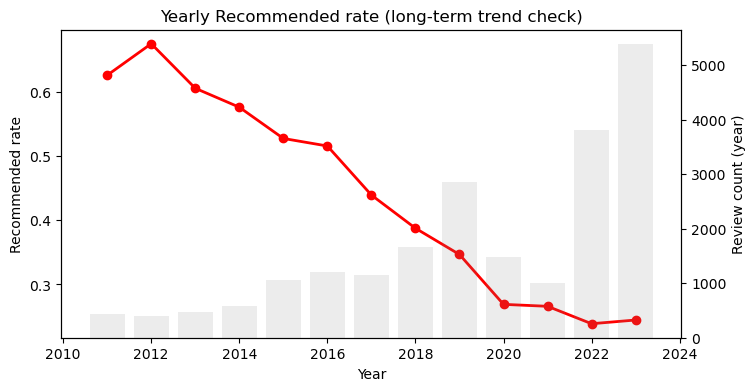

             recommended_rate  count
Review Date                         
2011                 0.625282    443
2012                 0.674300    393
2013                 0.605042    476
2014                 0.575601    582
2015                 0.527014   1055
2016                 0.515302   1209
2017                 0.439024   1148
2018                 0.387425   1670
2019                 0.346625   2859
2020                 0.269101   1479
2021                 0.266073   1011
2022                 0.238982   3812
2023                 0.244746   5377


In [209]:
# Check long-term trend in Recommended rate

import matplotlib.pyplot as plt

sorted_by_date = pd.concat([splits["A"]["train"], splits["A"]["test"]]).sort_values(
    ["Review Date", ID_COL], kind="stable"
).reset_index(drop=True)

sorted_by_date["year"] = sorted_by_date["Review Date"].dt.year
yearly_counts = sorted_by_date["year"].value_counts()

# Identify the minumum number of samples
p = sorted_by_date[TARGET].mean() 
margin = 0.05  # margin allowance ±5%p
z = 1.96  # 95% confidence level
min_n = (z**2 * p * (1-p)) / (margin**2)
print(f"Minimum Sample: {min_n:.0f}")

# Exclude years with fewer than sample number threshold (too sparse to be reliable)
valid_years = yearly_counts[yearly_counts >= min_n].index
filtered = sorted_by_date[sorted_by_date["year"].isin(valid_years)]

yearly_avg = filtered.set_index("Review Date")[TARGET].resample("Y").mean()
yearly_avg.index = yearly_avg.index.year

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(yearly_avg.index, yearly_avg.values, marker="o", color="red", linewidth=2)
ax1.set_ylabel("Recommended rate")
ax1.set_xlabel("Year")
ax1.set_title("Yearly Recommended rate (long-term trend check)")

ax2 = ax1.twinx()
ax2.bar(yearly_avg.index, yearly_counts.reindex(yearly_avg.index), alpha=0.15, color="gray")
ax2.set_ylabel("Review count (year)")

plt.show()

yearly_summary = pd.DataFrame({
    "recommended_rate": yearly_avg,
    "count": yearly_counts.reindex(yearly_avg.index),
})
print(yearly_summary)

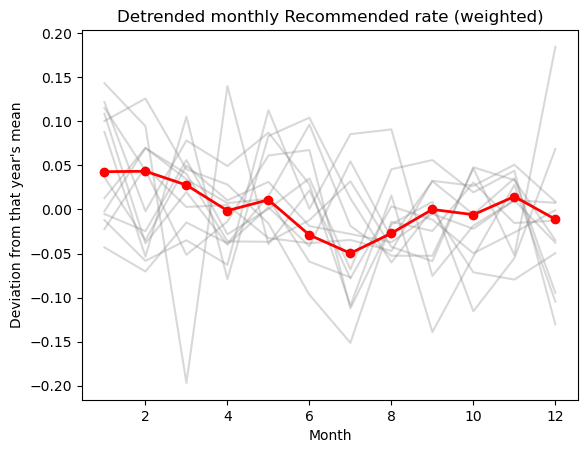

       weighted_mean  weighted_std
month                             
1           0.042805      0.050011
2           0.043301      0.060685
3           0.027637      0.038487
4          -0.001391      0.032064
5           0.010905      0.032370
6          -0.029005      0.046913
7          -0.049710      0.047383
8          -0.026989      0.034342
9           0.000004      0.042712
10         -0.005942      0.048016
11          0.014646      0.040525
12         -0.011155      0.060370


In [210]:
# Check if there is any seasonal variation (weighted, no arbitrary sample-count cutoff)

monthly_counts = filtered.set_index("Review Date")[TARGET].resample("M").count()
monthly_avg = filtered.set_index("Review Date")[TARGET].resample("M").mean()

# Subtract each year's mean to remove the long-term trend, keeping only within-year relative movement
detrended = monthly_avg.groupby(monthly_avg.index.year).transform(lambda x: x - x.mean())

detrended_df = pd.DataFrame({"value": detrended, "weight": monthly_counts})
detrended_df["year"] = detrended_df.index.year
detrended_df["month"] = detrended_df.index.month

# Overlay each year's detrended curve (gray) with the sample-weighted overall average (red)
detrended_df.pivot(index="month", columns="year", values="value").plot(
    legend=False, alpha=0.3, color="gray"
)

def weighted_mean(g):
    return np.average(g["value"], weights=g["weight"])

def weighted_std(g):
    avg = weighted_mean(g)
    variance = np.average((g["value"] - avg) ** 2, weights=g["weight"])
    return np.sqrt(variance)

monthly_summary = detrended_df.groupby("month").apply(
    lambda g: pd.Series({"weighted_mean": weighted_mean(g), "weighted_std": weighted_std(g)})
)

plt.plot(monthly_summary.index, monthly_summary["weighted_mean"],
          marker="o", color="red", linewidth=2)
plt.title("Detrended monthly Recommended rate (weighted)")
plt.ylabel("Deviation from that year's mean")
plt.xlabel("Month")
plt.show()

print(monthly_summary)

> ### **Key Insight**
>
> - **Yearly trend:** The chart above shows a clear long-term decline in `Recommended` rate, consistent across years rather than tied to any recurring cycle.
>
> - **Monthly pattern:** After removing each year's mean and weighting each (year, month)
  cell by its sample size, the standard deviation of detrended monthly values exceeds
  the mean deviation for 11 of 12 months (ratios ranging ~1.2x to >20x), indicating the
  fluctuation in those months is largely noise. July is the one exception, where the
  mean deviation (-0.0497) is comparable to or slightly exceeds the standard deviation
  (0.0474, ratio 0.95) -- a borderline signal worth flagging, but a single month out of
  twelve is not enough to establish a repeating annual pattern, especially without
  formal significance testing (not pursued here). Given this, any seasonal effect is at
  most weak and inconsistent across years, and **the test window does not need to span
  a full year purely to average out seasonal variation.**
>
> - **Implication for splitting:** The models do not take `Review Date` as an input, so they cannot explicitly learn this decline as a time-based trend. However, each model still implicitly anchors its predicted probabilities to the overall `Recommended` base rate seen during training. If the train window is dominated by earlier years with a higher base rate than the test period, the model may **systematically overpredict `Recommended` on test data**.
>
> - **Conclusion:**
> **Keeping the original chronological 80/20 split by row count**, rather than moving the cutoff to an earlier date, seems more logical. Extending the test window was originally motivated by a seasonality concern that the analysis above does not support strongly enough to justify shrinking the training set. Moreover, moving the cutoff does not actually close the train/test base-rate gap, as the gap is a property of the data's long-term trend, not an artifact of where the split falls, and no choice of cutoff resolves it.
> However, the target ratio (base rate) difference between train/test should be carried forward as an explicit modeling and evaluation consideration:
>
>    **1. ROC-AUC should be the primary metric for comparing Sets/models**, since it is relatively insensitive to differences in class prevalence between train and test. **PR-AUC should be interpreted relative to each split's own baseline (its positive rate)** rather than compared at face value across train and test, since its absolute value is directly driven by prevalence.
>   
>    **2. Threshold recalibration should be considered**, since a model trained on the higher train-period base rate may anchor its predicted probabilities to that base rate and **systematically overpredict `Recommended` on test data**, where the true positive rate is lower. This should be checked directly by comparing the model's predicted positive rate to the actual test positive rate before finalizing any threshold-based metrics (Accuracy, F1, confusion matrix).

## **3. Set A Imputation - Validated on the chronological train split**

In [211]:
# Unknown is excluded from this comparison, since 06_feature_sets.ipynb found including Unknown distorts the comparison.

def known_only_meandiff(df, group_col, cols, unknown_label="Unknown"):
    df_known = df[df[group_col] != unknown_label].copy()
    out = {}
    for col in cols:
        original = df_known[col].dropna()
        group_median = df_known.groupby(group_col)[col].transform("median")
        imputed = df_known[col].fillna(group_median)
        out[col] = round(abs(original.mean() - imputed.mean()), 4)
    return out

train_a = splits["A"]["train"]
seat_known = known_only_meandiff(train_a, "Seat Type", RATING_COLS)
trav_known = known_only_meandiff(train_a, "Type Of Traveller", RATING_COLS)

revalidation = pd.DataFrame({
    "Seat Type (train, known-only)": seat_known,
    "Type Of Traveller (train, known-only)": trav_known,
})
print(revalidation)

traveller_wins = (revalidation["Type Of Traveller (train, known-only)"] <
                   revalidation["Seat Type (train, known-only)"]).all()

# Hard stop if the train split ever disagrees with the conclusion from 06_feature_sets.ipynb.
assert traveller_wins, (
    "Type Of Traveller no longer outperforms Seat Type on ALL rating columns for this train split. "
    "Do not proceed with GroupMedianImputer(group_col='Type Of Traveller') below without re-examining this."
)
print(f"\n-> Type Of Traveller still outperforms Seat Type on ALL columns (chronological train): {traveller_wins}")


                     Seat Type (train, known-only)  Type Of Traveller (train, known-only)
Seat Comfort                                0.0573                                 0.0206
Cabin Staff Service                         0.0191                                 0.0090
Food & Beverages                            0.2099                                 0.0476
Ground Service                              0.2425                                 0.0604
Value For Money                             0.0026                                 0.0001

-> Type Of Traveller still outperforms Seat Type on ALL columns (chronological train): True


In [212]:
# GroupMedianImputer defaults to "Type Of Traveller", consistent with the validation in the cell above.
# This cell only checks that the imputer runs correctly (fit on train, transform test), with Unknown imputed with the overall median.

gmi = GroupMedianImputer(RATING_COLS).fit(splits["A"]["train"])
test_a_transformed = gmi.transform(splits["A"]["test"])
print("Remaining NaN in Set A rating cols after imputation (test split):")
print(test_a_transformed[RATING_COLS].isna().sum())

Remaining NaN in Set A rating cols after imputation (test split):
Seat Comfort           0
Cabin Staff Service    0
Food & Beverages       0
Ground Service         0
Value For Money        0
dtype: int64


## **4-6. Key Scaling / Encoding / Modelling Pipeline**

Implementation details are in `modelling_utils.py`. A few decisions worth calling out:

- **Binary columns (`Verified`, missing indicators) are excluded from scaling**, even in the Logistic Regression branch: StandardScaler divides by each column's own std, so an imbalanced binary flag gets scaled up far more than a balanced one — distorting how L2 regularization weighs it relative to other features.

- **Set C/D/E2 aspect NaNs are left as `NaN` for XGBoost/LightGBM** (native support), but 0-filled + missing-indicator for LR/RandomForest, since only the former handle missing values natively.

- **Tree models (RF/XGBoost/LightGBM) never scale anything** — they are scale-invariant, so scaling would add compute with no effect on results.

## **7. Model Fitting**

In [213]:
import os
import joblib
from modelling_utils import build_pipeline, SET_SCHEMA, TARGET

MODELS = ["LogisticRegression", "RandomForest", "XGBoost", "LightGBM"]
MODEL_DIR = "fitted_pipelines"
os.makedirs(MODEL_DIR, exist_ok=True)

fitted_pipelines = {}  # (set_name, model_name) -> fitted Pipeline

for set_name in SET_SCHEMA:
    y_train = splits[set_name]["train"][TARGET]
    X_train = splits[set_name]["train"].drop(columns=[TARGET])

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    for model_name in MODELS:
        pipe = build_pipeline(set_name, model_name, splits[set_name]["train"], scale_pos_weight)
        pipe.fit(X_train, y_train)

        fitted_pipelines[(set_name, model_name)] = pipe

        # Persist to disk so 08_hyperparameter_tuning.ipynb and 09_shap_analysis.ipynb can load these fitted pipelines in a separate kernel.
        joblib.dump(pipe, f"{MODEL_DIR}/{set_name}_{model_name}.joblib")

        print(f"fitted + saved: {set_name} / {model_name}")

print(f"\nTotal pipelines fitted: {len(fitted_pipelines)}")

fitted + saved: A / LogisticRegression
fitted + saved: A / RandomForest
fitted + saved: A / XGBoost
fitted + saved: A / LightGBM
fitted + saved: B / LogisticRegression
fitted + saved: B / RandomForest
fitted + saved: B / XGBoost
fitted + saved: B / LightGBM
fitted + saved: C / LogisticRegression
fitted + saved: C / RandomForest
fitted + saved: C / XGBoost
fitted + saved: C / LightGBM
fitted + saved: D / LogisticRegression
fitted + saved: D / RandomForest
fitted + saved: D / XGBoost
fitted + saved: D / LightGBM
fitted + saved: E1 / LogisticRegression
fitted + saved: E1 / RandomForest
fitted + saved: E1 / XGBoost
fitted + saved: E1 / LightGBM
fitted + saved: E2 / LogisticRegression
fitted + saved: E2 / RandomForest
fitted + saved: E2 / XGBoost
fitted + saved: E2 / LightGBM

Total pipelines fitted: 24


## **8. Evaluate Models: Forward-Chaining CV (train) + Held-out Test**

In [214]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score)

SCORING = {"accuracy": "accuracy", "precision": "precision", "recall": "recall",
           "f1": "f1", "roc_auc": "roc_auc", "pr_auc": "average_precision"}
tscv = TimeSeriesSplit(n_splits=5)

results = []
fold_scores = {}  # (set, model) -> per-fold roc_auc array, this is for Step 9: paired significance tests

for set_name in SET_SCHEMA:
    y_train = splits[set_name]["train"][TARGET]
    y_test = splits[set_name]["test"][TARGET]
    X_train = splits[set_name]["train"].drop(columns=[TARGET])
    X_test = splits[set_name]["test"].drop(columns=[TARGET])

    train_positive_rate = y_train.mean()
    test_positive_rate = y_test.mean()

    for model_name in MODELS:
        pipe = fitted_pipelines[(set_name, model_name)]

        # cross_validate clones + refits internally -> separate from the full-train fit stored in fitted_pipelines
        cv_pipe = build_pipeline(set_name, model_name, splits[set_name]["train"],
                                  scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())
        cv_res = cross_validate(cv_pipe, X_train, y_train, cv=tscv, scoring=SCORING, n_jobs=-1)
        fold_scores[(set_name, model_name)] = cv_res["test_roc_auc"]

        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1]

        predicted_positive_rate = y_pred.mean()

        results.append({
            "Set": set_name, "Model": model_name,
            "CV_F1_mean": cv_res["test_f1"].mean(), "CV_F1_std": cv_res["test_f1"].std(),
            "CV_ROC_AUC_mean": cv_res["test_roc_auc"].mean(), "CV_ROC_AUC_std": cv_res["test_roc_auc"].std(),
            "CV_PR_AUC_mean": cv_res["test_pr_auc"].mean(), "CV_PR_AUC_std": cv_res["test_pr_auc"].std(),
            "Test_Accuracy": accuracy_score(y_test, y_pred),
            "Test_Precision": precision_score(y_test, y_pred),
            "Test_Recall": recall_score(y_test, y_pred),
            "Test_F1": f1_score(y_test, y_pred),
            "Test_ROC_AUC": roc_auc_score(y_test, y_proba),
            "Test_PR_AUC": average_precision_score(y_test, y_proba),
            "Test_PR_AUC_baseline": test_positive_rate,  # random-classifier PR-AUC for this split
            "Train_positive_rate": train_positive_rate,
            "Test_positive_rate": test_positive_rate,
            "Predicted_positive_rate": predicted_positive_rate,  # threshold=0.5 diagnostic
        })

results_df = pd.DataFrame(results).sort_values("Test_ROC_AUC", ascending=False).reset_index(drop=True)

pd.set_option("display.width", 160)
print(results_df.round(4).to_string(index=False))


Set              Model  CV_F1_mean  CV_F1_std  CV_ROC_AUC_mean  CV_ROC_AUC_std  CV_PR_AUC_mean  CV_PR_AUC_std  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC  Test_PR_AUC  Test_PR_AUC_baseline  Train_positive_rate  Test_positive_rate  Predicted_positive_rate
  A LogisticRegression      0.9187     0.0097           0.9817          0.0093          0.9702         0.0066         0.9541          0.8705       0.9454   0.9064        0.9861       0.9664                0.2352               0.3592              0.2352                   0.2554
  A           LightGBM      0.9181     0.0082           0.9822          0.0061          0.9697         0.0045         0.9526          0.8672       0.9426   0.9034        0.9854       0.9643                0.2352               0.3592              0.2352                   0.2557
  A            XGBoost      0.9166     0.0073           0.9808          0.0058          0.9661         0.0061         0.9539          0.8755       0.9371   0.9053    

In [215]:
# Add confusion matrices for the combinations with the largest overprediction gap to see the gap driven by false positives

from sklearn.metrics import confusion_matrix

gap_check = results_df[["Set", "Model", "Test_positive_rate", "Predicted_positive_rate"]].copy()
gap_check["Overprediction_gap"] = gap_check["Predicted_positive_rate"] - gap_check["Test_positive_rate"]
print("=== Predicted vs Actual positive rate (threshold=0.5 diagnostic) ===")
print(gap_check.sort_values("Overprediction_gap", ascending=False).to_string(index=False))

top_gap = gap_check.sort_values("Overprediction_gap", ascending=False).head(3)

print("=== Confusion matrices for top overprediction-gap combinations ===")
for _, row in top_gap.iterrows():
    set_name, model_name = row["Set"], row["Model"]
    pipe = fitted_pipelines[(set_name, model_name)]
    X_test = splits[set_name]["test"].drop(columns=[TARGET])
    y_test = splits[set_name]["test"][TARGET]
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{set_name} / {model_name}  (gap={row['Overprediction_gap']:+.4f})")
    display(pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

=== Predicted vs Actual positive rate (threshold=0.5 diagnostic) ===
Set              Model  Test_positive_rate  Predicted_positive_rate  Overprediction_gap
  C LogisticRegression            0.235205                 0.289817            0.054613
  B LogisticRegression            0.235205                 0.279591            0.044386
  D LogisticRegression            0.235205                 0.270453            0.035248
  C           LightGBM            0.235205                 0.267406            0.032202
  C            XGBoost            0.235205                 0.266319            0.031114
  B           LightGBM            0.235205                 0.261314            0.026110
  D           LightGBM            0.235205                 0.259138            0.023934
  B            XGBoost            0.235205                 0.257615            0.022411
  A           LightGBM            0.235205                 0.255657            0.020453
  A LogisticRegression            0.235205         

,Pred 0,Pred 1
Actual 0,3090,425
Actual 1,174,907



B / LogisticRegression  (gap=+0.0444)


,Pred 0,Pred 1
Actual 0,3173,342
Actual 1,138,943



D / LogisticRegression  (gap=+0.0352)


,Pred 0,Pred 1
Actual 0,3222,293
Actual 1,131,950


> ### **Key Insight**
>
> As expected, the higher `Recommended` rate in train (35.9%) versus test (23.5%) causes
> most models to overpredict the positive class at the default threshold (0.5) — the
> confusion matrices above confirm this: false positives consistently outnumber false
> negatives for the largest-gap combinations.
>
> This uses default hyperparameters and threshold=0.5, so it's meant to confirm that
> the problem exists, not fix it. Threshold calibration is deferred to
> `08_hyperparameter_tuning.ipynb`, applied **only to the final tuned model**
> (not all 24 baseline combinations), using train-side CV validation folds only — the
> test set is never used to choose the threshold to aviod data leakage.

## **9. Set x Model Comparison**

In [216]:
from scipy.stats import wilcoxon

pivot = results_df.pivot(index="Set", columns="Model", values="Test_ROC_AUC")
pivot = pivot[MODELS]
rank_pivot = pivot.rank(ascending=False).astype(int)

print("=== Test ROC-AUC by Set x Model ===")
print(pivot.round(4))
print("\n=== Rank of each Set WITHIN each Model (1 = best) ===")
print(rank_pivot)

best_per_set = results_df.loc[results_df.groupby("Set")["Test_ROC_AUC"].idxmax()]
print("\n=== Best model per Set ===")
print(best_per_set[["Set", "Model", "Test_F1", "Test_ROC_AUC"]].to_string(index=False))

# TimeSeriesSplit(n_splits=5) gives only 5 paired observations per comparison.
# Wilcoxon signed-rank test has low power at this sample size, so p-values here should
# be read as directional/suggestive, not as confirmatory evidence of significance.
def paired_compare(set1, set2, label):
    print(f"--- {label}: {set1} vs {set2} ---")
    for model_name in MODELS:
        a = fold_scores[(set1, model_name)]
        b = fold_scores[(set2, model_name)]
        diff = a - b
        try:
            stat, p = wilcoxon(a, b)
        except ValueError:
            # all paired differences are exactly zero
            p = float("nan")
        winner = set1 if diff.mean() > 0 else set2
        sig = "significant" if p < 0.05 else "not significant"
        print(f"  {model_name:20s} {set1}={a.mean():.4f}  {set2}={b.mean():.4f}  "
              f"mean_diff={diff.mean():+.4f}  wilcoxon p={p:.4f}  -> {winner} higher ({sig}, n=5 folds)")
    print()

paired_compare("A", "E1", "Numeric vs BERT (full inference)")
paired_compare("B", "C", "VADER (document) vs Rule-based (aspect)")
paired_compare("C", "E1", "Rule-based vs BERT (full inference)")
paired_compare("C", "E2", "Rule-based vs BERT (keyword-gated)")
paired_compare("B", "E1", "VADER (document) vs BERT (full inference)")

=== Test ROC-AUC by Set x Model ===
Model  LogisticRegression  RandomForest  XGBoost  LightGBM
Set                                                       
A                  0.9861        0.9826   0.9830    0.9854
B                  0.9455        0.9413   0.9396    0.9440
C                  0.9239        0.9307   0.9393    0.9410
D                  0.9504        0.9474   0.9465    0.9516
E1                 0.9664        0.9624   0.9668    0.9681
E2                 0.9577        0.9591   0.9624    0.9654

=== Rank of each Set WITHIN each Model (1 = best) ===
Model  LogisticRegression  RandomForest  XGBoost  LightGBM
Set                                                       
A                       1             1        1         1
B                       5             5        5         5
C                       6             6        6         6
D                       4             4        4         4
E1                      2             2        2         2
E2                      

> ### **How to Read the Wilcoxon p-values**
>
> With only `TimeSeriesSplit(n_splits=5)`, each paired comparison has just 5 observations.
> At this sample size, Wilcoxon signed-rank test p-values are discrete — only a few values are mathematically possible, and none can reach the conventional p<0.05 threshold no matter how consistent the pattern is. Both 0.0625 and 0.1250 are technically "not significant" (p ≥ 0.05) — but this is a structural ceiling caused by having only 5 folds, not evidence of a weak or absent effect.
>
| Fold agreement | p-value | What it means |
|---|---|---|
| 5 / 5 folds agree in direction | 0.0625 | Perfect consistency — strongest possible signal at n=5 |
| 4 / 5 folds agree (smallest-margin fold flips) | 0.1250 | Near-perfect consistency |
| More mixed | 0.1875+ | Weak/no consistent direction |
>
>
> ### **How we interpret it in this project**
>
| Interpretation | Correct? |
|---|---|
| "Set A and Set E1 perform the same" | ❌ No — the data shows A winning across all 4 models (and nearly every CV fold) |
| "Set A is proven better than Set E1" | ❌ No — p<0.05 was not reached, so this can't be claimed |
| "Set A shows a consistent, directional advantage over Set E1, but the small sample (n=5 folds) prevents formal statistical confirmation" | ✅ Yes — this is the accurate reading |
>
> I treat p=0.0625/0.1250 results as strong **directional evidence, not formal
> significance**. The Set ranking (**A > E1 > E2 > D > B > C**) is corroborated by
> multiple independent lines of evidence — consistency across all 4 model families,
> consistency across CV folds, and persistence after hyperparameter tuning — even
> though no single Wilcoxon test alone clears p<0.05.

## **10. Save Results**

In [217]:
import os

metrics_dir = "../3_results/01_metrics/"
figures_dir = "../3_results/02_figures/"
os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# Naming convention: {STAGE}_{content}.csv
# STAGE distinguishes this baseline (default hyperparameters) run from the tuned run in 08_hyperparameter_tuning.ipynb.
STAGE = "baseline"
prefix = STAGE

# 1. Full per-(Set, Model) results table (Step 8)
results_df.to_csv(f"{metrics_dir}{prefix}_results.csv", index=False)
print(f"Saved: {metrics_dir}{prefix}_results.csv")

# 2. Set x Model ROC-AUC pivot + rank (Step 9)
pivot.to_csv(f"{metrics_dir}{prefix}_roc_auc_pivot.csv")
rank_pivot.to_csv(f"{metrics_dir}{prefix}_roc_auc_rank.csv")
print(f"Saved: {metrics_dir}{prefix}_roc_auc_pivot.csv")
print(f"Saved: {metrics_dir}{prefix}_roc_auc_rank.csv")

# 3. Best model per Set
best_per_set.to_csv(f"{metrics_dir}{prefix}_best_per_set.csv", index=False)
print(f"Saved: {metrics_dir}{prefix}_best_per_set.csv")

# 4. Paired significance test results — collect into a DataFrame instead of only printing
paired_results = []
comparisons = [
    ("A", "E1", "Numeric vs BERT (full inference)"),
    ("B", "C", "VADER (document) vs Rule-based (aspect)"),
    ("C", "E1", "Rule-based vs BERT (full inference)"),
    ("C", "E2", "Rule-based vs BERT (keyword-gated)"),
    ("B", "E1", "VADER (document) vs BERT (full inference)"),
]
for set1, set2, label in comparisons:
    for model_name in MODELS:
        a = fold_scores[(set1, model_name)]
        b = fold_scores[(set2, model_name)]
        diff = a - b
        try:
            stat, p = wilcoxon(a, b)
        except ValueError:
            p = float("nan")
        winner = set1 if diff.mean() > 0 else set2
        paired_results.append({
            "Comparison": label, "Set1": set1, "Set2": set2, "Model": model_name,
            "Set1_mean_ROC_AUC": a.mean(), "Set2_mean_ROC_AUC": b.mean(),
            "Mean_diff": diff.mean(), "Wilcoxon_p": p, "Winner": winner,
            "Significant_at_0.05": p < 0.05,
        })
paired_df = pd.DataFrame(paired_results)
paired_df.to_csv(f"{metrics_dir}{prefix}_paired_tests.csv", index=False)
print(f"Saved: {metrics_dir}{prefix}_paired_tests.csv")

Saved: ../3_results/01_metrics/baseline_results.csv
Saved: ../3_results/01_metrics/baseline_roc_auc_pivot.csv
Saved: ../3_results/01_metrics/baseline_roc_auc_rank.csv
Saved: ../3_results/01_metrics/baseline_best_per_set.csv
Saved: ../3_results/01_metrics/baseline_paired_tests.csv


- **baseline_results.csv:** Full metrics for all 24 (Set, Model) combinations — the raw source table
- **baseline_roc_auc_pivot.csv:** Test_ROC_AUC reshaped into a Set x Model matrix
- **baseline_roc_auc_rank.csv:** The matrix above converted to within-model rank (1 = best)
- **baseline_best_per_set.csv:** The best-performing model for each Set
- **baseline_paired_tests.csv:** Wilcoxon paired significance tests between Set pairs, across all 4 models